# 12.1. Lista Encadeada Simples

In [ ]:
# É uma lista onde cada item aponta pro próximo, tipo uma corrente:
# Cada "No" é uma caixinha da lista
class No:
    def __init__(self, dado):
        self.dado = dado      # valor guardado na caixinha
        self.prox = None      # ponteiro pro próximo nó (começa vazio)


# Essa é a lista em si
class ListaEncadeada:
    def __init__(self):
        self.inicio = None    # começo da lista (vazia no início)

    # inserir no final da lista
    def inserir(self, dado):
        novo_no = No(dado)    # cria uma nova caixinha com o valor

        # se a lista estiver vazia
        if not self.inicio:
            self.inicio = novo_no  # esse nó vira o primeiro
            return

        # se já tem elementos, vamos até o final
        atual = self.inicio       # começa pelo primeiro nó

        while atual.prox:         # enquanto tiver próximo
            atual = atual.prox    # vai andando até o último

        atual.prox = novo_no      # liga o último nó ao novo nó

    # mostrar a lista
    def exibir(self):
        atual = self.inicio       # começa do início

        while atual:              # enquanto existir nó
            print(f"{atual.dado} ->", end=" ")  # mostra valor
            atual = atual.prox    # vai pro próximo

        print("$")                # marca o fim da lista

    # remover um valor da lista
    def remover(self, chave):
        atual = self.inicio       # começa do início
        anterior = None           # guarda o nó anterior (começa vazio)

        # Caso 1: o nó a ser removido é o primeiro
        if atual and atual.dado == chave:
            self.inicio = atual.prox   # início passa a ser o próximo
            atual = None               # apaga referência
            return

        # Percorrer a lista procurando o valor
        while atual and atual.dado != chave:
            anterior = atual           # guarda o atual como anterior
            atual = atual.prox         # vai pro próximo

        # valor não encontrado
        if not atual:
            print("O valor não se encontra na lista")
            return

        # valor encontrado: remover da lista
        anterior.prox = atual.prox     # "pula" o nó removido
        atual = None                   # apaga referência

    # liberar espaço da lista com o Garbage Collector
    def liberar(self):
        self.inicio = None             # perde referência de toda lista
        print("Espaço da lista liberado")

    # liberar espaço da lista manualmente
    def liberar_manual(self):
        atual = self.inicio            # começa do início

        while atual:                   # enquanto tiver nó
            proximo_no = atual.prox    # guarda o próximo antes de apagar

            # limpar dados do nó atual
            atual.dado = None
            atual.prox = None

            del atual                 # apaga o nó da memória

            atual = proximo_no        # vai pro próximo

        self.inicio = None            # lista fica vazia
        print("Espaço da lista liberado")

In [ ]:
# TESTANDO -------------------------------
lista = ListaEncadeada()

valores = [10, 20, 30, 40, 50]

for v in valores:
    lista.inserir(v)

print("Lista inicial:")
lista.exibir()

# valor fixo para remover
remover_valor = 30
print(f"Removendo: {remover_valor}")
lista.remover(remover_valor)

lista.exibir()

lista.liberar_manual()          # liberar lista
lista.inserir(2)                # inserir novo valor fixo

print("Lista após liberar e inserir 2:")
lista.exibir()

Lista inicial:
10 -> 20 -> 30 -> 40 -> 50 -> $
Removendo: 30
10 -> 20 -> 40 -> 50 -> $
Espaço da lista liberado
Lista após liberar e inserir 2:
2 -> $


# 12.2. Lista Duplamente Encadeada

In [ ]:
# É uma lista onde cada item aponta para o próximo e para o anterior
# Cada "No" é uma caixinha da lista ---------------------------------------
class Nodo:
    def __init__(self, dado):
        self.dado = dado        # valor guardado na caixinha
        self.proximo = None     # ponteiro para o próximo nó
        self.anterior = None    # ponteiro para o nó anterior


# Essa é a lista em si ---------------------------------------
class ListaDuplamenteEncadeada:
    def __init__(self):
        self.cabeca = None      # começo da lista (lista começa vazia)


    # inserir no inicio da lista ---------------------------------------
    def inserir_inicio(self, dado):
        novo_nodo = Nodo(dado)          # cria um novo nó com o valor

        if self.cabeca is None:         # se a lista estiver vazia
            self.cabeca = novo_nodo     # o novo nó vira a cabeça
            return                      # termina a função

        novo_nodo.proximo = self.cabeca     # novo nó aponta para a antiga cabeça
        self.cabeca.anterior = novo_nodo    # antiga cabeça aponta para o novo nó (para trás)
        self.cabeca = novo_nodo             # agora a cabeça passa a ser o novo nó


    # inserir no final da lista ---------------------------------------
    def inserir_final(self, dado):
        novo_nodo = Nodo(dado)          # cria novo nó

        if self.cabeca is None:         # se a lista estiver vazia
            self.cabeca = novo_nodo     # novo nó vira a cabeça
            return

        atual = self.cabeca             # começa pela cabeça
        while atual.proximo:            # percorre até o último nó
            atual = atual.proximo

        atual.proximo = novo_nodo       # último nó aponta para o novo nó
        novo_nodo.anterior = atual      # novo nó aponta para o último nó


    # remover do inicio ---------------------------------------
    def remover_inicio(self):
        if self.cabeca is None:         # se a lista estiver vazia
            return None

        removido = self.cabeca.dado     # guarda o valor que será removido
        self.cabeca = self.cabeca.proximo  # cabeça passa a ser o próximo nó

        if self.cabeca:                 # se a lista não ficou vazia
            self.cabeca.anterior = None # remove o ponteiro para trás

        return removido                 # retorna o valor removido


    # remover do final ---------------------------------------
    def remover_final(self):
        if self.cabeca is None:         # se lista vazia
            return None

        atual = self.cabeca             # começa pela cabeça

        # se só tem um elemento
        if atual.proximo is None:
            self.cabeca = None          # lista fica vazia
            return atual.dado

        while atual.proximo:            # percorre até o último
            atual = atual.proximo

        valor = atual.dado              # guarda valor do último nó
        atual.anterior.proximo = None   # penúltimo passa a apontar para None

        return valor                    # retorna valor removido


    # mostrar a lista (normal) ---------------------------------------
    def exibir(self):
        atual = self.cabeca             # começa pela cabeça
        elementos = []                  # lista auxiliar para armazenar valores

        while atual:                    # percorre a lista
            elementos.append(str(atual.dado))  # adiciona valor na lista
            atual = atual.proximo       # vai para o próximo nó

        print(" <-> ".join(elementos))  # imprime a lista formatada

In [ ]:
# TESTANDO -------------------------------
lista = ListaDuplamenteEncadeada( )
lista.inserir_inicio(1)
lista.inserir_inicio(3)
lista.inserir_inicio(5)
lista.inserir_final(2)
lista.inserir_final(4)
lista.inserir_final(6)

print("Lista original: ", end=" ")
lista.exibir()
elemento = lista.remover_inicio()
print(f"Elemento {elemento} removido da lista")
print("Lista alterada: ", end=" ")
lista.exibir()
elemento = lista.remover_inicio()
print(f"Elemento {elemento} removido da lista")
print("Lista alterada: ", end=" ")
lista.exibir()

Lista original:  5 <-> 3 <-> 1 <-> 2 <-> 4 <-> 6
Elemento 5 removido da lista
Lista alterada:  3 <-> 1 <-> 2 <-> 4 <-> 6
Elemento 3 removido da lista
Lista alterada:  1 <-> 2 <-> 4 <-> 6


#
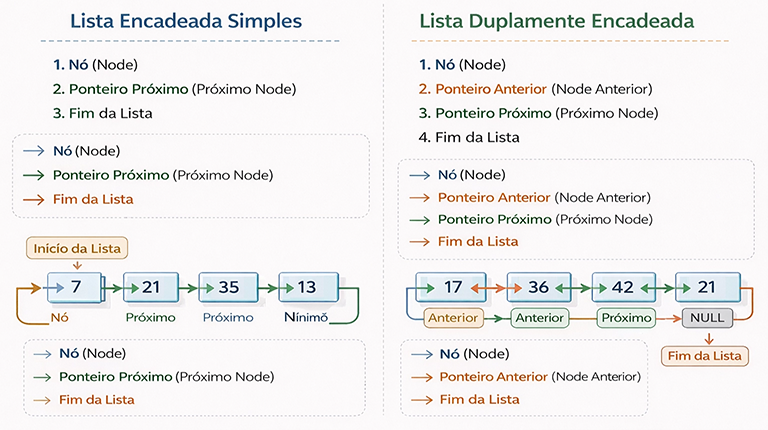